In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 10.2-4 &mdash; correlating vapor-liquid equilibrium data

**Illustration 10.2-4** and its two figures, for benzene / 2,2,4-trimethyl pentane at
55 °C. This is the chapter's data-reduction illustration: it starts from measured
$x$-$y$-$P$ points and works *backwards* to activity coefficients, an excess Gibbs energy,
and a smooth correlation that can be evaluated anywhere.

Two steps, and they are different in kind:

**(a) Reduction.** Each measured point gives one activity coefficient per species
directly, $\gamma_i = y_iP/x_iP_i^{\rm vap}$. No model, no fitting &mdash; just the
equilibrium relation rearranged. What comes out is seven isolated points.

**(b) Correlation.** A Redlich-Kister expansion is fitted to those points, giving an
expression that is differentiable and can be evaluated between them. That is the step
that turns data into something usable.

This notebook is load-bearing beyond Chapter 10: **the data in this illustration are the
data behind Figures 9.5-4 and 9.5-5**, and Chapter 9's correlation notebook takes its
seven points from this printed table rather than from the figure art.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.activity_models import RedlichKisterGex
from thermo.charts import use_book_style
use_book_style()
R = constants.R

## The measurements

Weissman and Wood, *J. Chem. Phys.* **32**, 1153 (1960), as printed in the illustration.
Seven points at 55 °C, and the two pure-component vapor pressures.

In [3]:
T = 273.15 + 55.0
xB = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
yB = np.array([0.1869, 0.4065, 0.5509, 0.5748, 0.6786, 0.8741, 0.9863])
P  = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])  # bar
Pvap_B, Pvap_TMP = 0.43596, 0.23738                                            # bar
xT, yT = 1 - xB, 1 - yB

## (a) Activity coefficients and $G^{\rm ex}$ from the data

At these pressures the vapor is nearly an ideal gas and the Poynting and fugacity
corrections are small, so the equilibrium relation collapses to

$$x_i\gamma_iP_i^{\rm vap} = y_iP \qquad\Longrightarrow\qquad
  \gamma_i = \frac{y_iP}{x_iP_i^{\rm vap}}$$

and the excess Gibbs energy follows from Eq. 9.3-12,
$G^{\rm ex} = RT(x_1\ln\gamma_1 + x_2\ln\gamma_2)$.

Note what is *not* here: no model has been assumed. These numbers are the measurements
rearranged, which is why they are the thing a model must later reproduce.

⚠️ **"Small" is not "negligible", and this notebook later finds where the difference
matters.** The dropped corrections move $\gamma_i$ by about 2 % &mdash; nothing, at the
printed precision. They move the thermodynamic consistency test of Figure 10.2-7 across its
acceptance criterion. Keep the assumption in mind; it is revisited there.

In [4]:
gB = yB * P / (xB * Pvap_B)
gT = yT * P / (xT * Pvap_TMP)
gex = R * T * (xB * np.log(gB) + xT * np.log(gT))

book = [(1.408,1.003,84.68),(1.343,1.011,199.74),(1.250,1.046,296.73),(1.242,1.048,305.22),
        (1.158,1.116,352.63),(1.023,1.508,224.30),(1.000,1.968,23.97)]
print("     x_B     gamma_B          gamma_TMP        Gex (J/mol)")
print("                ours / printed    ours / printed     ours / printed")
for i in range(len(xB)):
    b = book[i]
    print(f"  {xB[i]:.4f}   {gB[i]:.3f} / {b[0]:.3f}     {gT[i]:.3f} / {b[1]:.3f}"
          f"     {gex[i]:7.2f} / {b[2]:7.2f}")

     x_B     gamma_B          gamma_TMP        Gex (J/mol)
                ours / printed    ours / printed     ours / printed
  0.0819   1.408 / 1.408     1.003 / 1.003       84.67 /   84.68
  0.2192   1.343 / 1.343     1.011 / 1.011      199.70 /  199.74
  0.3584   1.250 / 1.250     1.046 / 1.046      296.72 /  296.73
  0.3831   1.242 / 1.242     1.048 / 1.048      305.19 /  305.22
  0.5256   1.158 / 1.158     1.116 / 1.116      352.61 /  352.63
  0.8478   1.023 / 1.023     1.508 / 1.508      224.28 /  224.30
  0.9872   1.000 / 1.000     1.968 / 1.968       23.96 /   23.97


Every one of the fourteen activity coefficients matches the printed value exactly, and
$G^{\rm ex}$ to the last digit or one in the last place. That is the expected result for
part (a) &mdash; there is no modeling freedom in it.

## (b) A Redlich-Kister correlation

Weissman and Wood used the three-term expansion of Eq. 9.5-6,

$$G^{\rm ex} = x_1x_2\left[a + b(x_1 - x_2) + c(x_1 - x_2)^2\right]$$

which is **linear in its coefficients**, so fitting it is one least-squares solve with no
starting guess and nothing to converge. Differentiating with respect to mole number gives
the activity coefficients (the illustration's Eqs. 2 and 3); `RedlichKisterGex` carries
both the expansion and its derivatives.

There are **two different sets of coefficients** in play here, and the difference is
the most instructive thing in the illustration.

In [5]:
printed = RedlichKisterGex([1389.0, 419.45, 109.83])   # the constants the illustration prints
fitted  = RedlichKisterGex.fit_gex(xB, gex, order=2)   # ours, from the seven points

# Weissman and Wood's OWN smoothing, from their Eqs. (8)-(10) -- coefficients as
# functions of temperature, in cal/mol.  See excess_properties_benzene_TMP_figure.
Tc = T
ww = 4.184 * np.array([2428.10 - 10.9940*Tc + 0.013961*Tc**2,
                       -1113.1 + 7.662*Tc - 0.01207*Tc**2,
                       33.0 - 0.027*Tc])

print("Redlich-Kister coefficients (J/mol)      a         b         c")
print(f"  as printed in the illustration    {1389.0:8.2f}  {419.45:8.2f}  {109.83:8.2f}")
print(f"  least squares on the 7 points     {fitted.a[0]:8.2f}  {fitted.a[1]:8.2f}  {fitted.a[2]:8.2f}")
print(f"  difference                        {100*(fitted.a[0]/1389.0-1):+7.1f} % {100*(fitted.a[1]/419.45-1):+8.1f} %"
      f" {100*(fitted.a[2]/109.83-1):+8.1f} %")
print(f"\n  Weissman and Wood's own, Eqs. (8)-(10) at 55 C")
print(f"                                    {ww[0]:8.2f}  {ww[1]:8.2f}  {ww[2]:8.2f}")

Redlich-Kister coefficients (J/mol)      a         b         c
  as printed in the illustration     1389.00    419.45    109.83
  least squares on the 7 points      1392.46    430.40     96.46
  difference                           +0.2 %     +2.6 %    -12.2 %

  Weissman and Wood's own, Eqs. (8)-(10) at 55 C
                                     1354.67    424.50    101.00


### The third coefficient is 12 % off, and that is not a bug

It would be easy to treat that gap as an error and tune it away. It is not one.

$c$ is the coefficient the data constrains **least**: it multiplies $(x_1-x_2)^2$, which is
small everywhere except near the pure ends, and that is exactly where seven points are
thinnest. A shift of a few hundredths of a J/mol in the fit lands almost entirely in $c$.
Note that the fitted curve is no worse than the printed one &mdash; the RMS residuals a few
cells below are 0.0083 and 0.0081 in $\ln\gamma$, indistinguishable.

⛔ **What the printed constants are NOT.** An earlier version of this notebook said they
were Weissman and Wood's own, fitted to their full data set with the corrections this
illustration drops. Reading the paper (*J. Chem. Phys.* **32**, 1153) settles it, and that
explanation was wrong on both halves. Their Eqs. (8) to (10) give the coefficients as
functions of temperature, and at 55 °C they come to the third row above &mdash; not the
printed ones. Nor do the dropped corrections account for the gap: applying their virial
correction to these seven points moves $a$ *further* from 1389, to about 1347. The printed
constants sit within 0.25 % of a plain least-squares fit to the seven points **as this
illustration reduces them**, so they are the book's own fit to its own numbers.

That does not change what to do with them, and the rule survives intact: **use the printed
coefficients to reproduce the book, use your own fit to fit your own data, and say which you
did.** Never adjust a constant to close a gap between the two. It changes only the story
told about where they came from &mdash; which is worth getting right, because the same
question comes back in the consistency test below with a different answer.

Everything below uses the printed coefficients, because the point is to reproduce the
illustration's smoothed table.

In [6]:
gB_s = np.array([printed.gamma([x, 1-x], T)[0] for x in xB])
gT_s = np.array([printed.gamma([x, 1-x], T)[1] for x in xB])
gex_s = np.array([printed.gex([x, 1-x], T) for x in xB])
dGmix = gex_s + R*T*(xB*np.log(xB) + xT*np.log(xT))

bk = [(1.428,1.002,83.85,-689.40),(1.342,1.013,203.34,-1231.56),(1.261,1.039,294.09,-1486.24),
      (1.246,1.046,306.52,-1509.50),(1.166,1.107,351.75,-1535.95),(1.023,1.508,223.72,-940.02),
      (1.000,1.961,24.02,-162.88)]
print("     x_B    gamma_B        gamma_TMP      Gex             dGmix (J/mol)")
for i in range(len(xB)):
    b = bk[i]
    print(f"  {xB[i]:.4f}  {gB_s[i]:.3f}/{b[0]:.3f}    {gT_s[i]:.3f}/{b[1]:.3f}"
          f"    {gex_s[i]:7.2f}/{b[2]:7.2f}   {dGmix[i]:9.2f}/{b[3]:9.2f}")

     x_B    gamma_B        gamma_TMP      Gex             dGmix (J/mol)
  0.0819  1.428/1.428    1.002/1.002      83.84/  83.85     -689.34/  -689.40
  0.2192  1.342/1.342    1.013/1.013     203.34/ 203.34    -1231.50/ -1231.56
  0.3584  1.261/1.261    1.039/1.039     294.11/ 294.09    -1486.14/ -1486.24
  0.3831  1.246/1.246    1.046/1.046     306.51/ 306.52    -1509.40/ -1509.50
  0.5256  1.166/1.166    1.107/1.107     351.77/ 351.75    -1535.83/ -1535.95
  0.8478  1.023/1.023    1.508/1.508     223.74/ 223.72     -939.94/  -940.02
  0.9872  1.000/1.000    1.961/1.961      24.03/  24.02     -162.87/  -162.88


All twenty-eight smoothed values reproduce. Note that $\Delta G_{\rm mix}$ is
$G^{\rm ex}$ plus the ideal contribution $RT\sum x_i\ln x_i$ &mdash; which is large and
negative, and is what makes the mixture form at all. $G^{\rm ex}$ is a few hundred J/mol;
the ideal term is nearly two thousand.

## Figure 1 &mdash; $G^{\rm ex}$ and $\Delta G_{\rm mix}$

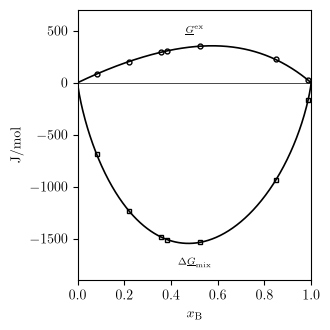

In [7]:
xg = np.linspace(1e-6, 1-1e-6, 400)
gex_c = np.array([printed.gex([x, 1-x], T) for x in xg])
dG_c = gex_c + R*T*(xg*np.log(xg) + (1-xg)*np.log(1-xg))

fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.plot(xg, gex_c, "-", color="k", lw=1.2)
ax.plot(xg, dG_c, "-", color="k", lw=1.2)
ax.plot(xB, gex, "o", mfc="none", color="k", ms=3.5)
ax.plot(xB, dGmix, "s", mfc="none", color="k", ms=3.5)
ax.axhline(0, color="k", lw=0.5)
ax.text(0.5, 480, r"$\underline{G}^{\rm ex}$", fontsize=7, ha="center")
ax.text(0.5, -1750, r"$\Delta\underline{G}_{\rm mix}$", fontsize=7, ha="center")
ax.set_xlabel(r"$x_{\rm B}$"); ax.set_ylabel("J/mol")
ax.set_xlim(0, 1); ax.set_ylim(-1900, 700)
fig.tight_layout()

## Figure 2 &mdash; the partial pressures

$P_{\rm B} = y_{\rm B}P$ and $P_{\rm TMP} = y_{\rm TMP}P$ against the liquid composition,
with the Raoult's law lines dashed. Both species show **positive deviation** &mdash; every
measured partial pressure lies above its ideal line &mdash; which is the same statement as
$\gamma_i > 1$ everywhere in the table above, read off a picture instead of a column.

The 5e draws this on **twin ordinates**, benzene left and 2,2,4-trimethyl pentane
right, at a 2:1 ratio. Both are pressures in bar, so one axis carries them both without
distortion and without asking the reader to check which scale a curve belongs to; that is
the departure taken here.

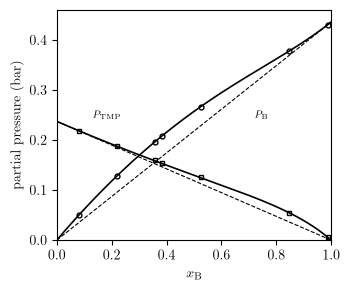

In [8]:
fig, ax = plt.subplots(figsize=(3.6, 3.0))
ax.plot([0, 1], [0, Pvap_B], "--", color="k", lw=0.8)
ax.plot([0, 1], [Pvap_TMP, 0], "--", color="k", lw=0.8)
ax.plot(xB, yB * P, "o", mfc="none", color="k", ms=3.5)
ax.plot(xB, yT * P, "s", mfc="none", color="k", ms=3.5)

pB_c = np.array([printed.gamma([x, 1-x], T)[0] for x in xg]) * xg * Pvap_B
pT_c = np.array([printed.gamma([x, 1-x], T)[1] for x in xg]) * (1-xg) * Pvap_TMP
ax.plot(xg, pB_c, "-", color="k", lw=1.2)
ax.plot(xg, pT_c, "-", color="k", lw=1.2)
ax.text(0.72, 0.245, r"$P_{\rm B}$", fontsize=7)
ax.text(0.13, 0.245, r"$P_{\rm TMP}$", fontsize=7)
ax.set_xlabel(r"$x_{\rm B}$"); ax.set_ylabel("partial pressure (bar)")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.46)
fig.tight_layout()

## What Chapter 9 takes from here

Chapter 9's `activity_coefficient_correlation_benzene_TMP_example` fits the one-constant
Margules and van Laar models to **these seven points**, and Figures 9.5-4 and 9.5-5 are
that comparison. The regular-solution and UNIFAC notebooks predict the same seven.

So this illustration is the source for four figures in two chapters, and the numbers above
are the check on all of them: the experimental $\gamma$ column here is the column those
notebooks fit to. If it ever moves, they move.

In [9]:
from thermo.activity_models import VanLaar, fit_binary

# van Laar by least squares on both species' ln gamma -- the second half of
# Illustration 9.5-1, fitted to exactly the seven points reduced above.
vl = fit_binary(VanLaar, xB, gB, gT, T=T)
print(f"van Laar fitted to these seven points:  alpha = {vl.alpha:.4f}, beta = {vl.beta:.4f}")

rms = lambda g: np.sqrt(np.mean((np.log(g[:, 0]) - np.log(gB))**2
                                + (np.log(g[:, 1]) - np.log(gT))**2))
print("\nRMS residual in ln gamma over the seven points, both species:")
for nm, mdl in (("Redlich-Kister, printed a,b,c", printed),
                ("Redlich-Kister, fitted here  ", fitted),
                ("van Laar, fitted here        ", vl)):
    g = np.array([mdl.gamma([x, 1 - x], T) for x in xB])
    print(f"  {nm}  {rms(g):.4f}")

# The one-constant Margules of Fig. 9.5-4 is NOT fitted by least squares: Chapter 9
# sets one constant per species from that species' infinite-dilution value, which is
# the route the printed figure uses. See ch9/activity_coefficient_correlation_*.

van Laar fitted to these seven points:  alpha = 0.3877, beta = 0.7102

RMS residual in ln gamma over the seven points, both species:
  Redlich-Kister, printed a,b,c  0.0081
  Redlich-Kister, fitted here    0.0083
  van Laar, fitted here          0.0071


## Figure 10.2-7 &mdash; the thermodynamic consistency test

The chapter's one purely thermodynamic check on experimental activity coefficients. Starting
from the Gibbs-Duhem equation, Eq. 10.2-14 requires

$$\int_{x_1=0}^{x_1=1}\ln\frac{\gamma_2}{\gamma_1}\,{\rm d}x_1 = 0$$

for isothermal data whose total-pressure variation is small &mdash; which is this data set. The
integrand changes sign once, so the requirement is that the area above the axis and the area
below it be equal. The chapter accepts data when

$$-0.02 \le \frac{|{\rm area\ I}| - |{\rm area\ II}|}{|{\rm area\ I}| + |{\rm area\ II}|} \le 0.02$$

**There is a trap in this figure, and it is the reason to compute it rather than look at it.**
A thermodynamically consistent activity coefficient model satisfies the Gibbs-Duhem equation
*by construction*, so its two areas are equal to machine precision no matter what data it was
fitted to. A curve drawn through the points by way of the Redlich-Kister correlation therefore
**cannot fail this test**. The test only means something applied to the measured activity
coefficients themselves.

Both are computed below, and they do not agree.

In [10]:
# The integrand, from the EXPERIMENTAL activity coefficients (Sec. (a) above)
consistency = np.log(gT / gB)                    # ln(gamma_2/gamma_1), Eq. 10.2-14
xg7 = np.linspace(0.0, 1.0, 4001)

def areas(x, f):
    """|area above the axis|, |area below| for f(x) sampled on x."""
    return (abs(np.trapezoid(np.where(f > 0, f, 0.0), x)),
            abs(np.trapezoid(np.where(f < 0, f, 0.0), x)))

def ratio(f_on_grid):
    I, II = areas(xg7, f_on_grid)
    return I, II, (I - II) / (I + II)

# (1) the smoothing the illustration itself uses
smooth = np.array([np.log(printed.gamma([x, 1-x], T)[1] / printed.gamma([x, 1-x], T)[0])
                   for x in xg7])
I, II, r = ratio(smooth)
print(f"  Redlich-Kister smoothing:  |I| = {I:.5f}, |II| = {II:.5f},  ratio = {r:+.6f}")
print("     -- exactly zero, and it had to be: the model obeys Gibbs-Duhem by construction.\n")

# (2) the seven measured points, interpolated several ways, because the answer depends on
#     how the curve is carried to the pure ends and that dependence is part of the result
from scipy.interpolate import CubicSpline, PchipInterpolator
schemes = [(f"polynomial, degree {d}", np.polyval(np.polyfit(xB, consistency, d), xg7))
           for d in (2, 3, 4)]
schemes += [("cubic spline", CubicSpline(xB, consistency)(xg7)),
            ("monotone (PCHIP)", PchipInterpolator(xB, consistency)(xg7)),
            ("linear, ends held flat", np.interp(xg7, xB, consistency))]
print("  the SEVEN MEASURED POINTS, carried to the pure ends six ways:")
print(f"    {'scheme':26s} {'|I|':>8s} {'|II|':>8s} {'ratio':>9s}   criterion")
for name, curve in schemes:
    I, II, r = ratio(curve)
    print(f"    {name:26s} {I:8.5f} {II:8.5f} {r:+9.4f}   "
          f"{'passes' if abs(r) <= 0.02 else 'FAILS'}")

  Redlich-Kister smoothing:  |I| = 0.13027, |II| = 0.13027,  ratio = +0.000000
     -- exactly zero, and it had to be: the model obeys Gibbs-Duhem by construction.

  the SEVEN MEASURED POINTS, carried to the pure ends six ways:
    scheme                          |I|     |II|     ratio   criterion
    polynomial, degree 2        0.13839  0.12445   +0.0530   FAILS
    polynomial, degree 3        0.13318  0.12491   +0.0320   FAILS
    polynomial, degree 4        0.13274  0.12392   +0.0344   FAILS
    cubic spline                0.13409  0.12213   +0.0467   FAILS
    monotone (PCHIP)            0.13401  0.12414   +0.0382   FAILS
    linear, ends held flat      0.13986  0.12225   +0.0672   FAILS


### Why it fails, and it is not the measurements

All six schemes fail, all with the same sign. Before concluding anything about the data,
there is a specific suspect to eliminate: **part (a) assumed an ideal vapor**, and
Weissman and Wood did not.

Their Eq. (2) carries two terms this illustration drops &mdash; a second-virial correction
to the vapor fugacity and a correction from the experimental pressure to a 1 atm reference:

$$\Delta\mu_1^{\rm E} = RT\ln\frac{Py_1}{P_1^{\rm vap}x_1}
   + (\beta_{11} - \underline{V}_1^{\rm L})(P - P_1^{\rm vap})
   + \delta y_2^2 P + (\bar V_1 - \underline{V}_1^{\rm L})(1 - P)$$

with $\delta = 2\beta_{12} - \beta_{11} - \beta_{22}$. Those are small in
$\underline{G}^{\rm ex}$ &mdash; about 2 % &mdash; but the consistency test is an integral
of a *difference* of logarithms, in which a systematic 2 % does not cancel. Their second
virial coefficients at 55 °C are in their Table III, and the whole test can simply be run
again with the correction restored.

In [11]:
# Weissman and Wood's Table III at 55 C, cm^3/mol, and delta = 2 B12 - B11 - B22
B11, B22, delta = -1122.0, -1910.0, 106.0
V_B, V_TMP = 78.114 / 0.8465, 114.23 / 0.6640      # pure liquid molar volumes at 55 C
CM3_ATM = 0.101325                                 # J per cm^3 atm
ATM = 1 / 1.01325                                  # atm per bar

Pa, P1a, P2a = P * ATM, Pvap_B * ATM, Pvap_TMP * ATM
d_B   = ((B11 - V_B)   * (Pa - P1a) + delta * yT**2 * Pa) * CM3_ATM   # J/mol
d_TMP = ((B22 - V_TMP) * (Pa - P2a) + delta * yB**2 * Pa) * CM3_ATM

# The correction is a check as well as a correction: with it, the reduced G^ex must
# reproduce Weissman and Wood's own dG_p^E column (Table II, 55 C) in cal/mol.
gex_corr = gex + xB * d_B + xT * d_TMP
ww_col = np.array([19.9, 46.3, 68.8, 70.8, 82.0, 52.5, 5.6])          # their Table II
print("  G^ex at 55 C, cal/mol:   ideal vapor / with Eq. (2) / Weissman and Wood")
for i in range(len(xB)):
    print(f"    x_B = {xB[i]:.4f}    {gex[i]/4.184:6.2f}   {gex_corr[i]/4.184:6.2f}"
          f"   {ww_col[i]:6.1f}")
print(f"\n  mean |residual| vs their column:  ideal vapor "
      f"{np.mean(abs(gex/4.184 - ww_col)):.2f}   corrected "
      f"{np.mean(abs(gex_corr/4.184 - ww_col)):.2f} cal/mol"
      f"   (their own smoothing rms is 0.4)")

# Now redo the area test on the CORRECTED activity coefficients
corrected = (np.log(gT) + d_TMP / (R * T)) - (np.log(gB) + d_B / (R * T))
print("\n  the same six schemes, with the vapor-phase correction restored:")
print(f"    {'scheme':26s} {'ratio, ideal':>13s} {'ratio, corrected':>18s}   criterion")
schemes_c = [(f"polynomial, degree {d}", np.polyval(np.polyfit(xB, corrected, d), xg7))
             for d in (2, 3, 4)]
schemes_c += [("cubic spline", CubicSpline(xB, corrected)(xg7)),
              ("monotone (PCHIP)", PchipInterpolator(xB, corrected)(xg7)),
              ("linear, ends held flat", np.interp(xg7, xB, corrected))]
for (name, ideal_curve), (_, corr_curve) in zip(schemes, schemes_c):
    r0 = ratio(ideal_curve)[2]
    r1 = ratio(corr_curve)[2]
    print(f"    {name:26s} {r0:+13.4f} {r1:+18.4f}   "
          f"{'passes' if abs(r1) <= 0.02 else 'FAILS'}")

print("\n  Weissman and Wood ran this test themselves and report area RATIOS I/II of")
print("  1.015, 1.026, 1.027 and 1.042 at 35, 45, 55 and 75 C.  In the chapter's")
print("  normalization (r-1)/(r+1) those are:")
print("   ", "  ".join(f"{t} C: {(r-1)/(r+1):+.4f}"
                       for t, r in ((35, 1.015), (45, 1.026), (55, 1.027), (75, 1.042))))

  G^ex at 55 C, cal/mol:   ideal vapor / with Eq. (2) / Weissman and Wood
    x_B = 0.0819     20.24    19.25     19.9
    x_B = 0.2192     47.73    45.62     46.3
    x_B = 0.3584     70.92    68.26     68.8
    x_B = 0.3831     72.94    70.24     70.8
    x_B = 0.5256     84.28    81.60     82.0
    x_B = 0.8478     53.60    52.35     52.5
    x_B = 0.9872      5.73     5.60      5.6

  mean |residual| vs their column:  ideal vapor 1.36   corrected 0.43 cal/mol   (their own smoothing rms is 0.4)

  the same six schemes, with the vapor-phase correction restored:
    scheme                      ratio, ideal   ratio, corrected   criterion
    polynomial, degree 2             +0.0530            +0.0050   passes
    polynomial, degree 3             +0.0320            -0.0168   passes
    polynomial, degree 4             +0.0344            -0.0148   passes
    cubic spline                     +0.0467            -0.0026   passes
    monotone (PCHIP)                 +0.0382            -0.010

### The chapter's sentence is right about the data and wrong about these numbers

Two results, and the order matters.

**As the illustration reduces them, the seven points fail.** Every way of carrying them to
the pure ends gives a ratio between **+0.032 and +0.067**, against a stated tolerance of
$\pm 0.02$, and the sign is the same in all six. The chapter says the two areas "are
virtually equal in size ... so that Eq. 10.2-14 can be considered satisfied." Of the
numbers it prints, that is not so.

**Restore the vapor-phase correction and every scheme passes.** The same seven measurements,
reduced the way Weissman and Wood reduced them, land between $-0.017$ and $+0.019$ &mdash;
inside the band, all six. And that is not a lucky choice of correction: the corrected
$\underline{G}^{\rm ex}$ column reproduces their own published
$\Delta\underline{G}_p^{\rm E}$ to 0.43 cal/mol, which is the root-mean-square scatter they
quote for it, where the ideal-vapor column is three times further out. The correction is
verified against the source before it is used to draw a conclusion.

**Their own answer agrees.** Weissman and Wood applied this test to all five isotherms and
report area ratios of 1.015, 1.026, 1.027 and 1.042 &mdash; $+0.007$ to $+0.021$ in the
chapter's normalization. Their data is consistent, as the chapter says it is.

⭐ **So the finding is not "the data is bad." It is that a Gibbs-Duhem area test is far more
sensitive to the vapor-phase correction than the activity coefficients it is built from.**
Those $\gamma_i$ shift by about 2 % when the correction is dropped &mdash; invisible at the
printed precision, where the table matches to the last digit either way. The consistency
ratio shifts by a factor of three and crosses the acceptance criterion. An integral of a
difference of logarithms does not forgive a systematic error the way a point value does.

⚠️ **And the figure as the 5e draws it cannot show any of this**, because a smooth curve
through the points is a *model* curve and the model has zero net area by construction. That
remains the more useful lesson for a student: **passing this test is a property of what you
drew, unless you drew the data.**

⬜ **For the author.** The chapter's sentence needs no correction &mdash; it is true of
Weissman and Wood's results. What it cannot claim is that the reader can verify it from the
illustration's own table, since doing so returns +0.03 to +0.07. One clause naming the
vapor-phase correction as the reason would make the paragraph self-consistent, and would
land in the same section that later spends a page on the fugacity coefficient.

  the integrand changes sign at x_1 = 0.568


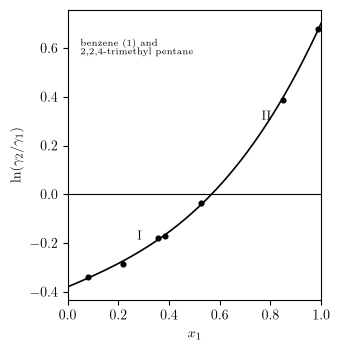

In [12]:
fig7, ax7 = plt.subplots(figsize=(3.5, 3.6))
best = np.polyval(np.polyfit(xB, consistency, 3), xg7)
ax7.axhline(0.0, color="k", lw=0.8)
ax7.plot(xg7, best, "-", color="k", lw=1.2)
ax7.plot(xB, consistency, "o", color="k", ms=3.4, lw=0)
# areas I and II labeled in the regions they name, as the printed figure does
zero = xg7[int(np.argmin(np.abs(best)))]
ax7.text(zero / 2, np.min(best) / 2.2, "I", fontsize=9, ha="center", va="center")
ax7.text((1 + zero) / 2, np.max(best) / 2.2, "II", fontsize=9, ha="center", va="center")
ax7.set_xlabel("$x_1$")
ax7.set_ylabel(r"$\ln(\gamma_2/\gamma_1)$")
ax7.set_xlim(0, 1)
ax7.text(0.05, 0.90, "benzene (1) and\n2,2,4-trimethyl pentane",
         transform=ax7.transAxes, fontsize=6.5, va="top")
fig7.tight_layout()
print(f"  the integrand changes sign at x_1 = {zero:.3f}")

**The orientation of this figure is changed from the 5e, deliberately.** The 5e's art plots
$\ln(\gamma_{\rm B}/\gamma_{\rm TMP})$, which with benzene as species 1 is
$\ln(\gamma_1/\gamma_2)$ &mdash; the reciprocal of what its own Eq. 10.2-14 and the paragraph
describing the figure both use. The curve above follows the equation, so area I is now the
negative lobe on the left and II the positive one on the right, mirrored from the printed
figure. Flipping back is one sign, if the author prefers the old orientation and a change to
the equation instead.

## Print art

In [13]:
# --- Print art: Illustration 10.2-4, Figures 1 and 2 -----------------------
# Stage as deliverables/figures/print-bw/ch10/c10uf006.pdf and c10uf007.pdf
#
# Both are UNNUMBERED in-illustration figures. Their captions were lost from the
# .docx (bare "Figure 1" / "Figure 2" slugs with no text) and recovered from the
# 5e page: Figure 1 is Gex and dGmix; Figure 2 is the partial pressures.
#
# Figure 2 is drawn on ONE ordinate where the 5e used twin axes at a 2:1 ratio --
# both curves are pressures in bar, so a single scale loses nothing and removes a
# reading hazard. Flag it to production; the caption needs no change.
import os
os.makedirs("pdf", exist_ok=True)

f, a = plt.subplots(figsize=(3.4, 3.4))
a.plot(xg, gex_c, "-", color="k", lw=1.2); a.plot(xg, dG_c, "-", color="k", lw=1.2)
a.plot(xB, gex, "o", mfc="none", color="k", ms=3.5)
a.plot(xB, dGmix, "s", mfc="none", color="k", ms=3.5)
a.axhline(0, color="k", lw=0.5)
a.text(0.5, 480, r"$\underline{G}^{\rm ex}$", fontsize=7, ha="center")
a.text(0.5, -1750, r"$\Delta\underline{G}_{\rm mix}$", fontsize=7, ha="center")
a.set_xlabel(r"$x_{\rm B}$"); a.set_ylabel("J/mol")
a.set_xlim(0, 1); a.set_ylim(-1900, 700)
f.tight_layout(); f.savefig("pdf/Illustration_10.2-4_fig1.pdf", dpi=300, bbox_inches="tight"); plt.close(f)

f, a = plt.subplots(figsize=(3.6, 3.0))
a.plot([0, 1], [0, Pvap_B], "--", color="k", lw=0.8)
a.plot([0, 1], [Pvap_TMP, 0], "--", color="k", lw=0.8)
a.plot(xB, yB*P, "o", mfc="none", color="k", ms=3.5)
a.plot(xB, yT*P, "s", mfc="none", color="k", ms=3.5)
a.plot(xg, pB_c, "-", color="k", lw=1.2); a.plot(xg, pT_c, "-", color="k", lw=1.2)
a.text(0.72, 0.245, r"$P_{\rm B}$", fontsize=7)
a.text(0.13, 0.245, r"$P_{\rm TMP}$", fontsize=7)
a.set_xlabel(r"$x_{\rm B}$"); a.set_ylabel("partial pressure (bar)")
a.set_xlim(0, 1); a.set_ylim(0, 0.46)
f.tight_layout(); f.savefig("pdf/Illustration_10.2-4_fig2.pdf", dpi=300, bbox_inches="tight"); plt.close(f)
print("wrote pdf/Illustration_10.2-4_fig1.pdf and _fig2.pdf")
# --- Print art: Figure 10.2-7 ----------------------------------------------
#   pdf/Fig_10.2-7.pdf -> deliverables/figures/print-bw/ch10/c10f019.pdf
# c10f019, NOT c10f007: the .docx slugs restart per section. The ordinate follows
# Eq. 10.2-14, ln(gamma_2/gamma_1), which mirrors the 5e's art -- see the note above.
fig7.savefig("pdf/Fig_10.2-7.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_10.2-7.pdf")

wrote pdf/Illustration_10.2-4_fig1.pdf and _fig2.pdf
wrote pdf/Fig_10.2-7.pdf


## Your turn

1. The fit above used `order=2`, three coefficients. Try `order=1` and `order=3`. Where
   does the extra freedom go, and at what order do you start fitting the rounding in the
   fourth digit rather than the chemistry?
2. $\Delta G_{\rm mix}$ is negative everywhere here, so the mixture forms at every
   composition. How large would $a$ have to be, holding $b = c = 0$, before
   $\Delta G_{\rm mix}$ develops two minima &mdash; the condition for liquid-liquid phase
   separation, which Chapter 11 takes up?
3. The consistency cell corrected the vapor with Weissman and Wood's second virial
   coefficients. Do it with the machinery of Chapter 9 instead: use `PRMixture` to compute
   $\bar\phi_i$ for this vapor, form $\gamma_i = y_i\bar\phi_iP/(x_iP_i^{\rm vap})$, and
   rerun the area test. Does an equation of state agree with their virial treatment about
   whether the data passes?
4. The consistency test moved by a factor of three under a 2 % change in the activity
   coefficients. Work out why from the definition: what is
   $\partial\!\left[\int_0^1\ln(\gamma_2/\gamma_1)\,{\rm d}x_1\right]$ when both
   $\ln\gamma_i$ are shifted by a smooth function of composition, and which shifts survive
   the integration?
5. This system's excess *enthalpy* and *entropy* cannot be had from one isotherm. See
   `excess_properties_benzene_TMP_figure`, which builds Figure 10.2-6 from all five of
   Weissman and Wood's temperatures &mdash; and quantifies what the differentiation costs.